In [105]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
import random
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42
LABELS = ["legit", "Fraud"]


In [106]:
credit_card_data = pd.read_csv('creditcard.csv')
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [107]:
credit_card_data.sample()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2887,2437,-0.344139,0.515851,0.740874,-2.327595,0.480129,-0.747351,0.937298,-0.145947,0.889503,...,0.038115,0.374858,-0.390164,-0.53811,0.095544,-0.79989,0.222787,-0.035918,1.0,0.0


In [108]:
# dataset informations
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15936 entries, 0 to 15935
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    15936 non-null  int64  
 1   V1      15936 non-null  float64
 2   V2      15936 non-null  float64
 3   V3      15936 non-null  float64
 4   V4      15936 non-null  float64
 5   V5      15936 non-null  float64
 6   V6      15936 non-null  float64
 7   V7      15936 non-null  float64
 8   V8      15936 non-null  float64
 9   V9      15936 non-null  float64
 10  V10     15936 non-null  float64
 11  V11     15936 non-null  float64
 12  V12     15936 non-null  float64
 13  V13     15936 non-null  float64
 14  V14     15936 non-null  float64
 15  V15     15936 non-null  float64
 16  V16     15936 non-null  float64
 17  V17     15936 non-null  float64
 18  V18     15936 non-null  float64
 19  V19     15936 non-null  float64
 20  V20     15936 non-null  float64
 21  V21     15936 non-null  float64
 22

In [109]:
# checking the number of missing values in each column
credit_card_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

In [110]:
# distribution of legit transactions & fraudulent transactions
credit_card_data['Class'].value_counts()

0.0    15862
1.0       73
Name: Class, dtype: int64

In [111]:
legit = credit_card_data[credit_card_data.Class==0]
fraud = credit_card_data[credit_card_data['Class']==1]


In [112]:
fraud['Class']

541      1.0
623      1.0
4920     1.0
6108     1.0
6329     1.0
        ... 
15566    1.0
15736    1.0
15751    1.0
15781    1.0
15810    1.0
Name: Class, Length: 73, dtype: float64

In [113]:
# statistical measures of the data
legit.Amount.describe()

count    15862.000000
mean        66.280151
std        188.898885
min          0.000000
25%          5.522500
50%         15.950000
75%         53.890000
max       7712.430000
Name: Amount, dtype: float64

In [114]:
fraud.Amount.describe()

count      73.000000
mean       90.307123
std       271.634360
min         0.000000
25%         1.000000
50%         1.000000
75%        99.990000
max      1809.680000
Name: Amount, dtype: float64

In [115]:
# compare the values for both transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,12104.432165,-0.219072,0.25000,0.862854,0.272641,-0.105868,0.124522,-0.112681,-0.016178,0.879120,...,0.028173,-0.064056,-0.161585,-0.035040,0.013076,0.117023,0.037111,0.011206,0.005907,66.280151
1.0,15559.643836,-7.929807,6.19312,-11.997831,6.555050,-5.474984,-2.480356,-8.354317,3.668478,-3.086988,...,0.671905,0.441100,-0.295856,-0.358994,-0.328925,0.216076,0.209323,0.927187,0.061380,90.307123


In [116]:
legit_sample = legit.sample(n=492)
new_df = pd.concat([legit_sample,fraud],axis=0)
new_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
9558,14324,-0.382982,2.692966,-1.790516,1.789234,0.905397,-1.316690,0.042522,-3.878924,1.275375,...,2.770862,-1.199051,0.594865,0.279195,-0.444105,-0.491569,-0.056429,-0.172238,0.89,0.0
14960,26266,-1.100777,0.252457,2.137915,1.241396,-0.206981,0.621238,0.343834,0.054364,-0.165581,...,0.161988,0.593952,-0.313920,-0.395967,0.469440,-0.022632,0.031000,0.137833,146.00,0.0
3332,2878,-0.800442,0.611450,0.604307,-1.555209,0.210315,0.216749,-0.184932,0.822022,-0.054442,...,-0.065414,-0.370519,-0.088063,-1.141397,-0.220997,0.812693,0.057076,-0.044241,2.31,0.0
4498,3803,1.191012,-0.219179,-0.179915,0.376612,1.607988,4.109250,-1.220414,1.007737,2.045119,...,-0.259920,-0.470804,-0.037468,0.940544,0.546935,-0.433266,0.046043,0.026879,19.90,0.0
8302,11084,1.052861,0.122419,0.658575,0.690618,0.195665,0.890361,-0.397005,0.323601,1.373195,...,-0.273037,-0.419762,0.322584,-0.717545,-0.182686,0.166148,0.012429,0.000016,1.98,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15566,26961,-23.237920,13.487386,-25.188773,6.261733,-17.345188,-4.534989,-17.100492,15.374630,-3.845567,...,1.769708,-1.691973,-1.045673,0.143386,1.611577,-0.221576,1.481233,0.438125,99.99,1.0
15736,27163,-23.914101,13.765942,-25.733734,6.290918,-17.784824,-4.572498,-17.390764,15.794136,-3.819832,...,1.773399,-1.748426,-1.093104,0.147807,1.663792,-0.221024,1.458076,0.430315,99.99,1.0
15751,27187,-24.590245,14.044567,-26.278701,6.320089,-18.224513,-4.609968,-17.681003,16.213627,-3.794093,...,1.777063,-1.804874,-1.140605,0.152234,1.715997,-0.220471,1.434951,0.422492,99.99,1.0
15781,27219,-25.266355,14.323254,-26.823673,6.349248,-18.664251,-4.647403,-17.971212,16.633103,-3.768351,...,1.780701,-1.861318,-1.188167,0.156667,1.768192,-0.219916,1.411855,0.414656,99.99,1.0


In [117]:
new_df['Class'].value_counts()

0.0    492
1.0     73
Name: Class, dtype: int64

In [118]:
new_df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,11842.264228,-0.297188,0.246978,0.857065,0.148641,-0.108505,0.065602,-0.109432,0.004314,0.921944,...,0.010563,-0.09739,-0.117204,-0.048766,0.059518,0.107402,0.050768,0.018281,0.005688,60.660061
1.0,15559.643836,-7.929807,6.193120,-11.997831,6.555050,-5.474984,-2.480356,-8.354317,3.668478,-3.086988,...,0.671905,0.44110,-0.295856,-0.358994,-0.328925,0.216076,0.209323,0.927187,0.061380,90.307123


In [119]:
X = new_df.drop(columns='Class', axis=1)
Y = new_df['Class']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [120]:
model=LogisticRegression()

In [121]:
# training the Logistic Regression Model with Training Data
model.fit(X_train, Y_train)
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy on Training data : ', training_data_accuracy)


Accuracy on Training data :  0.9889380530973452


C:\Users\saura\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [122]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score on Test Data : ', test_data_accuracy)

Accuracy score on Test Data :  0.9911504424778761


# Exploratory Data Analysis

Text(0, 0.5, 'Frequency')

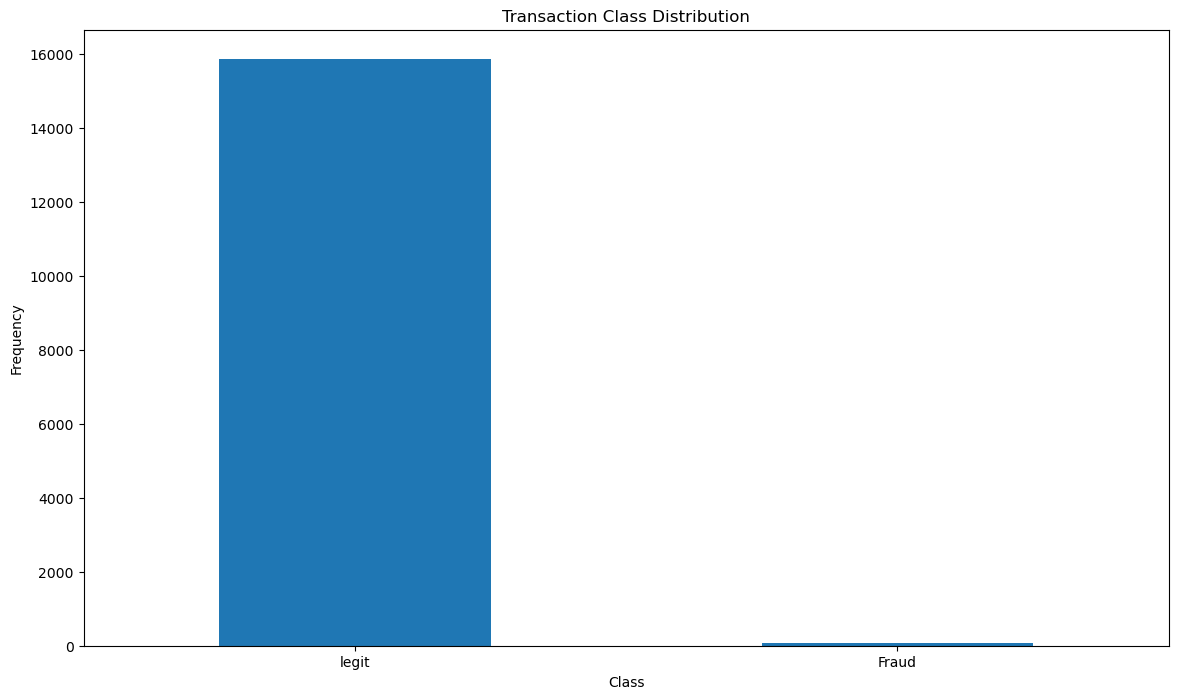

In [123]:
count_classes = pd.value_counts(credit_card_data['Class'], sort = True)

count_classes.plot(kind = 'bar', rot=0)

plt.title("Transaction Class Distribution")

plt.xticks(range(2), LABELS)

plt.xlabel("Class")

plt.ylabel("Frequency")

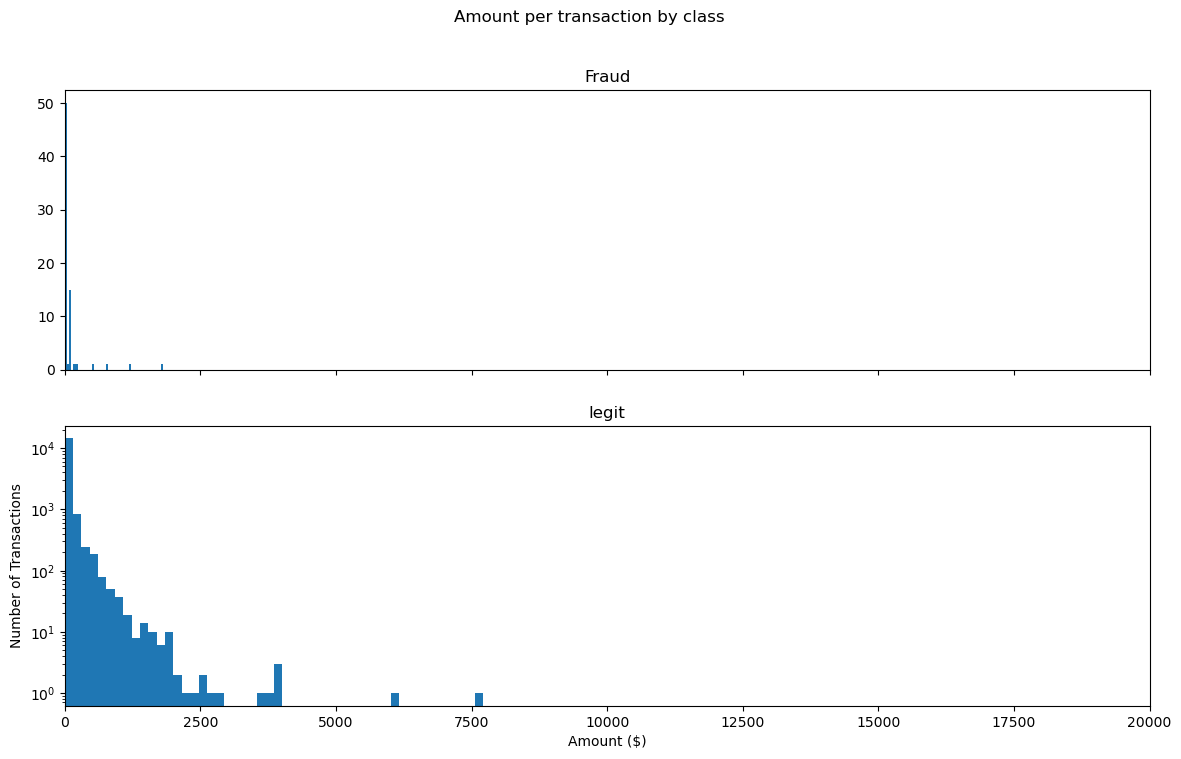

In [124]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(fraud.Amount, bins = bins)
ax1.set_title('Fraud')
ax2.hist(legit.Amount, bins = bins)
ax2.set_title('legit')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show();

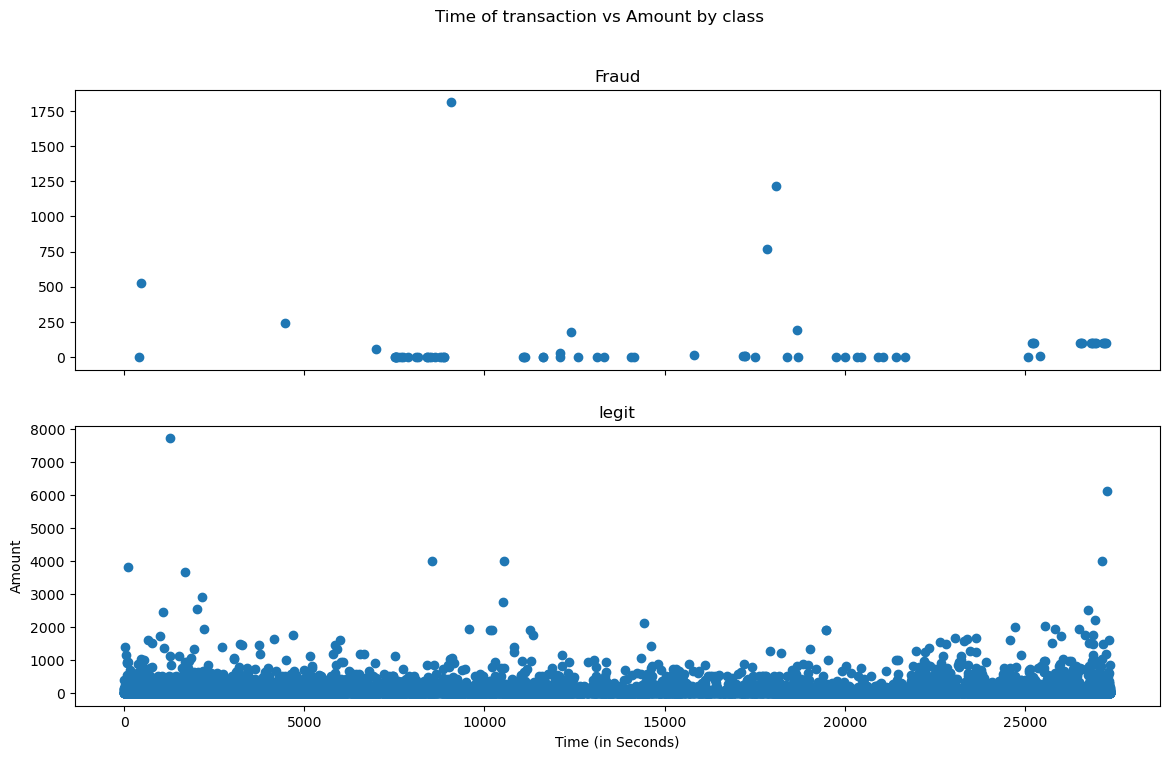

In [125]:
# We Will check Do fraudulent transactions occur more often during certain time frame ? Let us find out with a visual representation.

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')
ax1.scatter(fraud.Time, fraud.Amount)
ax1.set_title('Fraud')
ax2.scatter(legit.Time, legit.Amount)
ax2.set_title('legit')
plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

In [126]:
## Take some sample of the data

data1= credit_card_data.sample(frac = 0.1,random_state=1)

data1.shape

(1594, 31)

In [127]:
#Determine the number of fraud and valid transactions in the dataset
outlier_fraction = len(fraud)/float(len(legit))
print(outlier_fraction)

print("Fraud Cases : {}".format(len(fraud)))

print("Valid Cases : {}".format(len(legit)))

0.004602193922582272
Fraud Cases : 73
Valid Cases : 15862


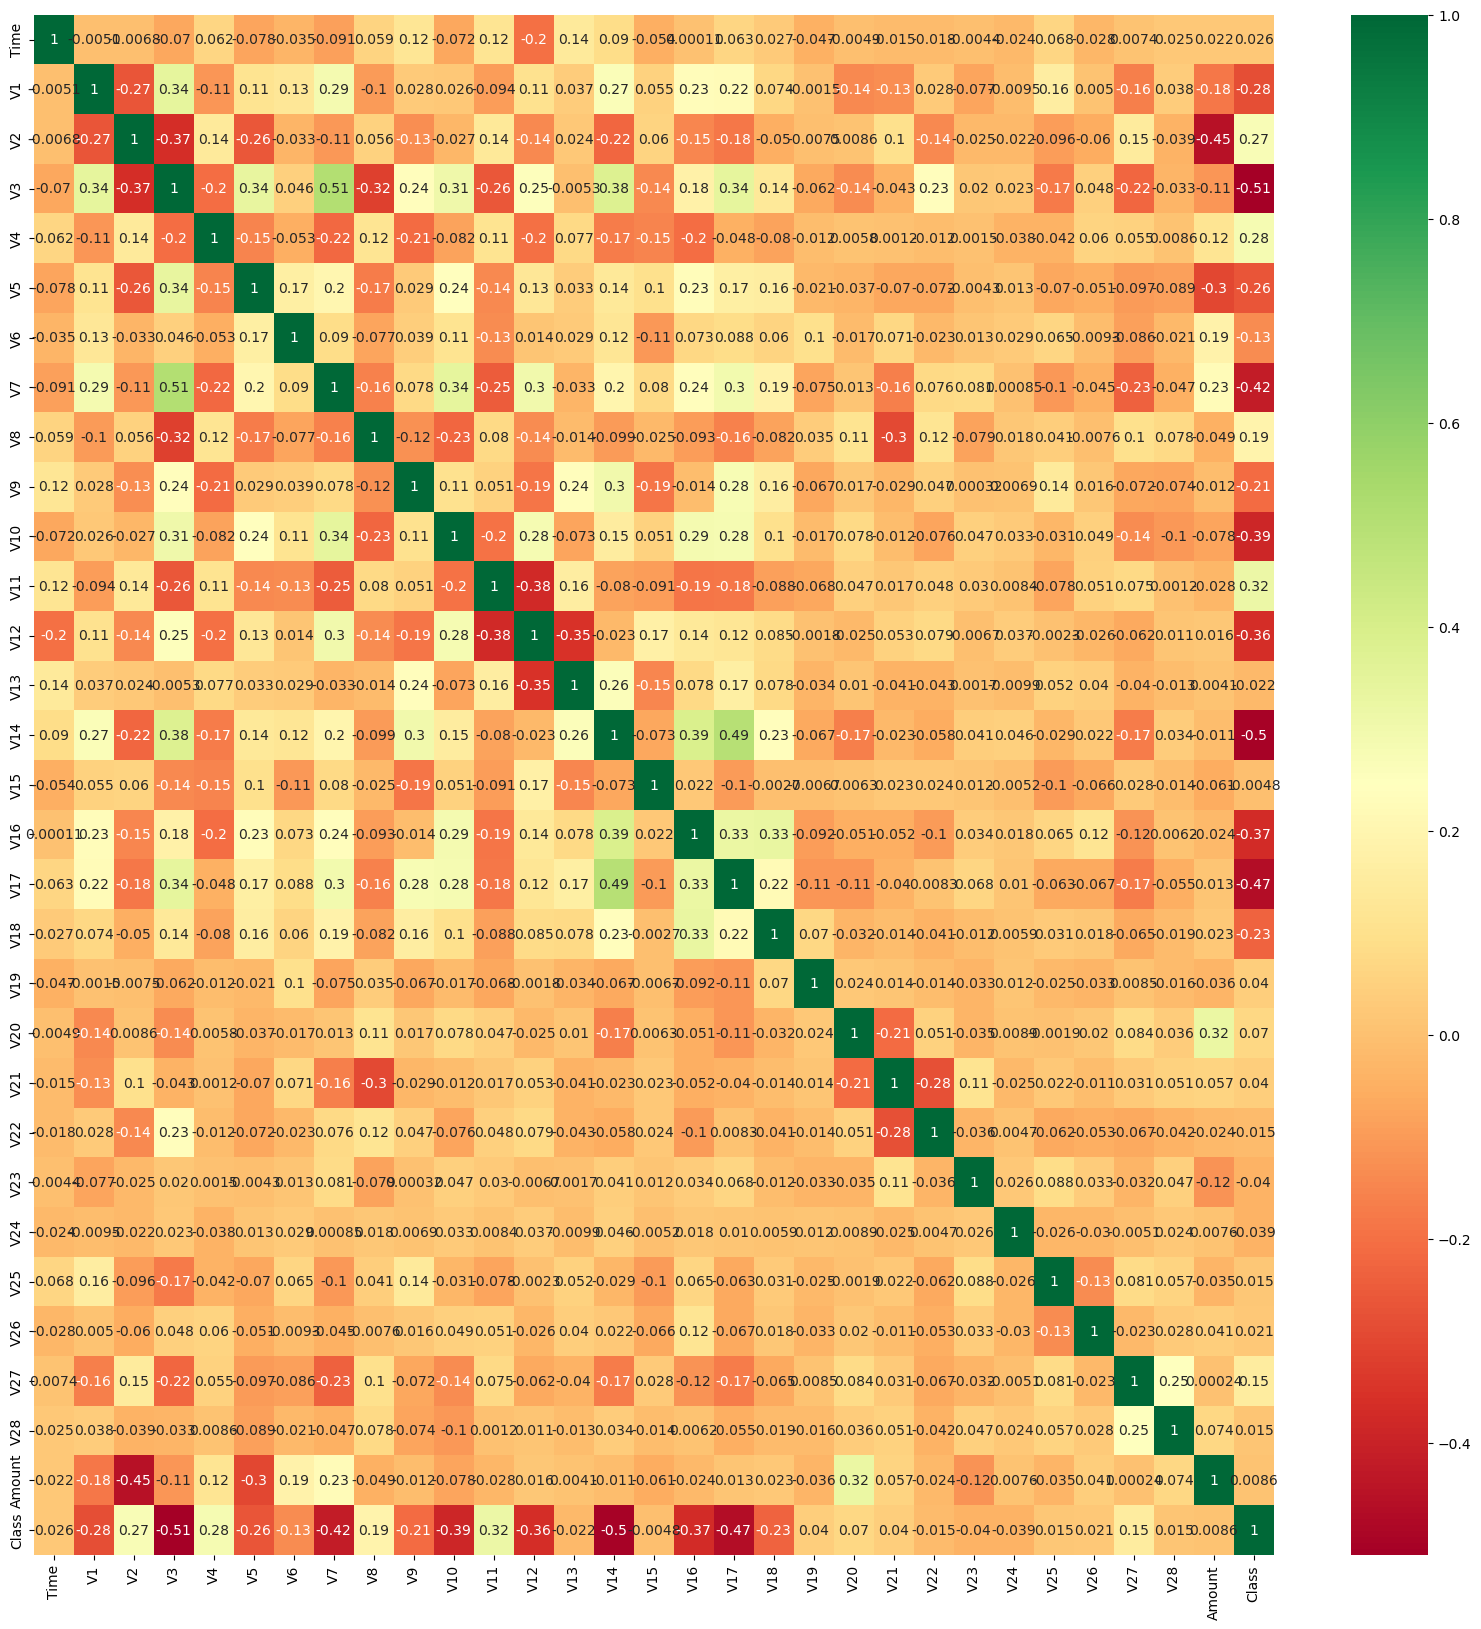

In [128]:
## Correlation
import seaborn as sns
#get correlations of each features in dataset
corrmat = data1.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(credit_card_data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [129]:
#Create independent and Dependent Features
columns = data1.columns.tolist()
# Filter the columns to remove data we do not want 
columns = [c for c in columns if c not in ["Class"]]
# Store the variable we are predicting 
target = "Class"
# Define a random state 
state = np.random.RandomState(42)
X = data1[columns]
Y = data1[target]
X_outliers = state.uniform(low=0, high=1, size=(X.shape[0], X.shape[1]))
# Print the shapes of X & Y
print(X.shape)
print(Y.shape)

(1594, 30)
(1594,)


# Model Prediction

Isolation Forest Algorithm : Local Outlier Factor(LOF) Algorithm : Support Vector Machine

In [138]:
classifiers = {
    "Isolation Forest":IsolationForest(n_estimators=100, max_samples=len(X), 
                                       contamination=outlier_fraction,random_state=state, verbose=0),
    "Local Outlier Factor":LocalOutlierFactor(n_neighbors=20, algorithm='auto', 
                                              leaf_size=30, metric='minkowski',
                                              p=2, metric_params=None, contamination=outlier_fraction),
    "Support Vector Machine":OneClassSVM(kernel='rbf', degree=3, gamma=0.1,nu=0.05, 
                                         max_iter=-1)
   
}

In [145]:
type(classifiers)

dict

In [150]:
n_outliers = len(fraud)
for i, (clf_name,clf) in enumerate(classifiers.items()):
    #Fit the data and tag outliers
    if clf_name == "Local Outlier Factor":
        y_pred = clf.fit_predict(X)
        scores_prediction = clf.negative_outlier_factor_
    elif clf_name == "Support Vector Machine":
        clf.fit(X)
        y_pred = clf.predict(X)
    else:    
        clf.fit(X)
        scores_prediction = clf.decision_function(X)
        y_pred = clf.predict(X)
    #Reshape the prediction values to 0 for Valid transactions , 1 for Fraud transactions
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1
    n_errors = (y_pred != Y).sum()
    # Run Classification Metrics
    print("{}: {}".format(clf_name,n_errors))
    print("Accuracy Score :")
    print(accuracy_score(Y,y_pred))
    print("Classification Report :")
    print(classification_report(Y,y_pred))

C:\Users\saura\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Isolation Forest: 11
Accuracy Score :
0.993099121706399
Classification Report :
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1585
         1.0       0.38      0.33      0.35         9

    accuracy                           0.99      1594
   macro avg       0.69      0.67      0.67      1594
weighted avg       0.99      0.99      0.99      1594

Local Outlier Factor: 17
Accuracy Score :
0.9893350062735258
Classification Report :
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1585
         1.0       0.00      0.00      0.00         9

    accuracy                           0.99      1594
   macro avg       0.50      0.50      0.50      1594
weighted avg       0.99      0.99      0.99      1594

Support Vector Machine: 605
Accuracy Score :
0.6204516938519448
Classification Report :
              precision    recall  f1-score   support

         0.0       0.99      0.62     